In [1]:
import pandas as pd

data = pd.read_csv("../data/clean_weather.csv", index_col=0)
data = data.ffill()

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

def PlotTimeSeries(df, img_name="data.svg", PlotOut=False):    
    df.index = pd.to_datetime(df.index)

    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Tmax e Tmin como linhas
    sns.lineplot(x=df.index.day, y=df["tmax"], ax=ax1, marker="o", label="Tmax", color="red", linewidth=2)
    sns.lineplot(x=df.index.day, y=df["tmin"], ax=ax1, marker="o", label="Tmin", color="blue", linewidth=2)
    if (PlotOut):
        sns.lineplot(x=df.index.day, y=df["tmax_tomorrow"], ax=ax1, marker="o", label="Tmax Tomorrow", color="orange", linestyle="dashed", linewidth=2)

    # Criando um segundo eixo para a precipitação (rain)
    ax2 = ax1.twinx()
    sns.barplot(x=df.index.day, y=df["rain"], ax=ax2, color="gray", alpha=0.3, label="Precipitação", width=0.6)

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Data", fontsize=12)
    ax1.set_ylabel("Temperatura (°C)", fontsize=12, color="black")
    ax2.set_ylabel("Precipitação ", fontsize=12, color="gray")

    # Rotacionando os rótulos das datas
    plt.xticks(rotation=45, fontsize=5)

    # Adicionando legendas
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    # Título
    plt.title("Variação de Temperatura e Precipitação", fontsize=14)
    plt.savefig(f"content/{img_name}", format="svg", dpi=600)
    # Exibindo o gráfico
    plt.show()

,tmax,tmin,rain,tmax_tomorrow
2022-10-26,-0.006853,-0.799242,-0.253661,69.0
2022-10-27,0.353349,-1.093694,-0.253661,65.0
2022-10-28,-0.126920,-0.946468,-0.253661,68.0
2022-10-29,0.233282,-1.240920,-0.253661,65.0
2022-10-30,-0.126920,0.084114,-0.253661,64.0
2022-10-31,-0.246987,-0.357564,-0.253661,60.0
2022-11-01,-0.727256,0.231340,0.909325,59.0
2022-11-02,-0.847323,-0.357564,-0.032140,60.0
2022-11-03,-0.727256,-1.535372,-0.253661,61.0
2022-11-04,-0.607189,-1.240920,-0.253661,61.0


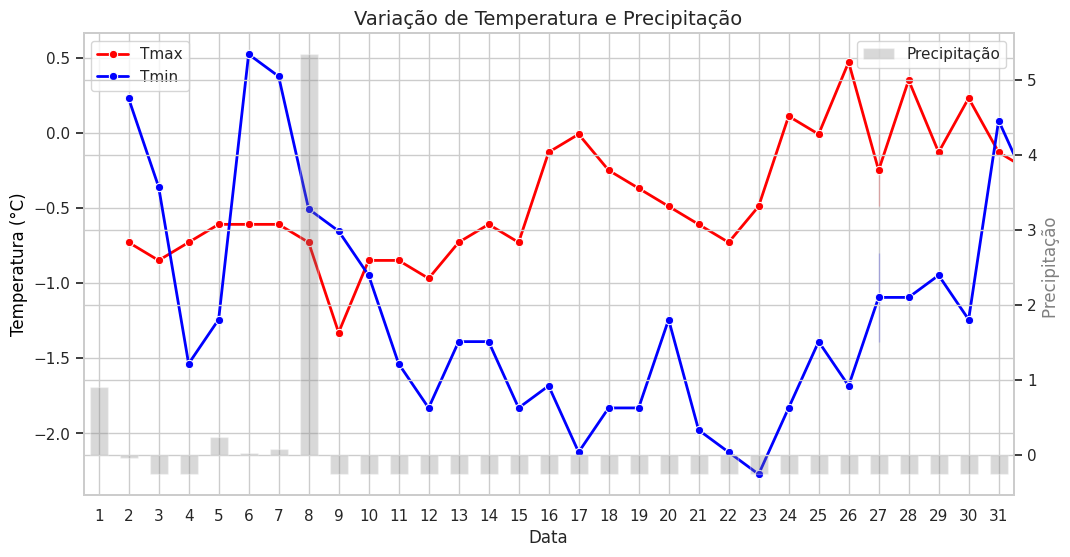

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define predictors and target
PREDICTORS = ["tmax", "tmin", "rain"]
TARGET = "tmax_tomorrow"

# Scale our data to have mean 0
scaler = StandardScaler()
data[PREDICTORS] = scaler.fit_transform(data[PREDICTORS])

# Random sampling doesn't make sense because we lose the time information
# data = data.sample(25, random_state=42)

#
data = data.tail(32)
display(data)
PlotTimeSeries(
    df = data
)
# Split into train (70%), validation (15%), and test (15%) sets
train_data, temp_data = train_test_split(data, test_size=0.3, shuffle=False)
valid_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False )

# Convertendo para arrays numpy
train_x = train_data[PREDICTORS].to_numpy()
train_y = train_data[[TARGET]].to_numpy()

x_val = valid_data[PREDICTORS].to_numpy()
y_val = valid_data[[TARGET]].to_numpy()

x_test = test_data[PREDICTORS].to_numpy()
y_test = test_data[[TARGET]].to_numpy()


In [4]:
import matplotlib.pyplot as plt
import keras
from keras import layers, models, regularizers
from keras.callbacks import EarlyStopping

def compile_model(model, epochs=100):
    # Compilando o modelo
    model.compile(loss="mse", optimizer="adam")

    # Definindo o early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


    # Treinando o modelo
    history = model.fit(
        train_x, train_y,
        epochs=epochs,
        validation_data=(x_val, y_val),
        callbacks=[early_stop],
        verbose=False
    )

    # Avaliando o modelo
    mse_v = model.evaluate(x_val, y_val)
    print(f"Validation MSE: {mse_v:.4f}")
    
    mse_t = model.evaluate(x_test, y_test)
    print(f"Test MSE: {mse_t:.4f}")

    # Plotando o histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()

2025-03-30 02:56:33.066277: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 02:56:38.004748: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 02:56:41.485801: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743303405.470865    1449 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743303406.345421    1449 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-30 02:56:55.037372: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins


Treinando modelo com hidden_size = 1


2025-03-30 02:57:11.858848: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1613.0620
Validation MSE: 1613.0620
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1974.1956
Test MSE: 1974.1956


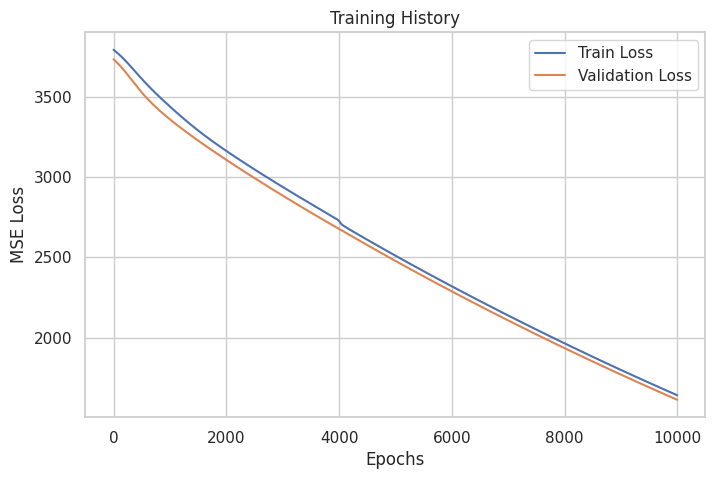


Treinando modelo com hidden_size = 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 48.9131
Validation MSE: 48.9131
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 128.6673
Test MSE: 128.6673


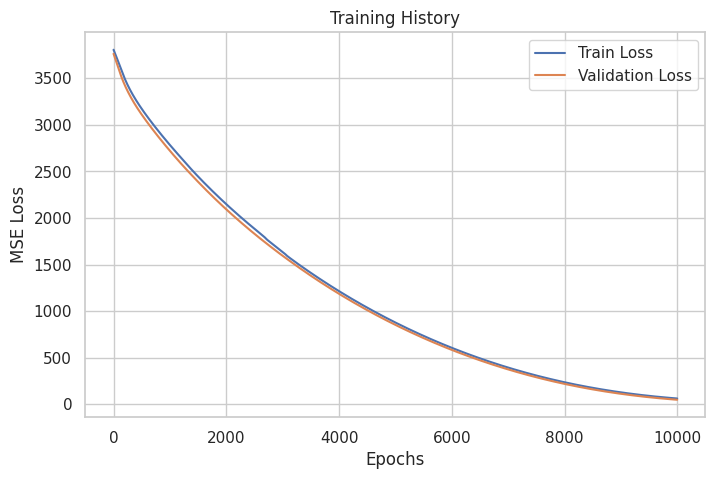


Treinando modelo com hidden_size = 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 4.3503
Validation MSE: 4.3503
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 28.8492
Test MSE: 28.8492


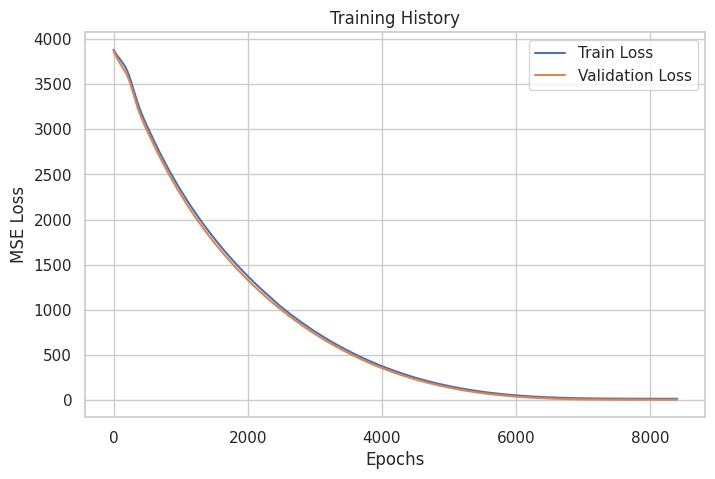


Treinando modelo com hidden_size = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.6067
Validation MSE: 3.6067
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 29.2838
Test MSE: 29.2838


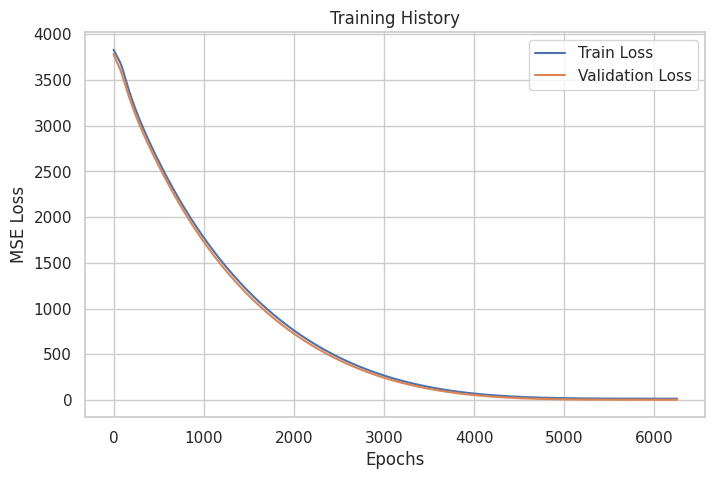


Treinando modelo com hidden_size = 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.1087
Validation MSE: 3.1087
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 25.9180
Test MSE: 25.9180


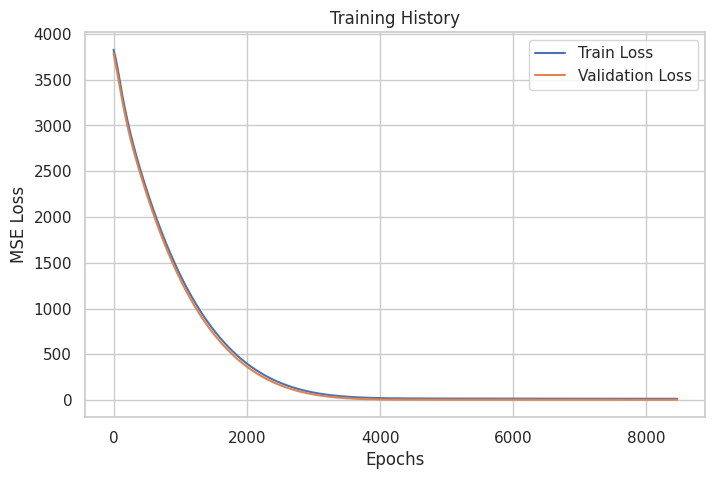


Treinando modelo com hidden_size = 25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 2.8611
Validation MSE: 2.8611
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 25.3065
Test MSE: 25.3065


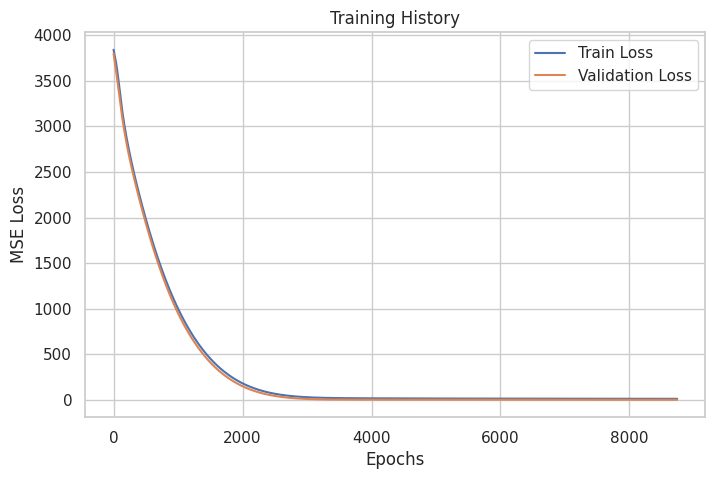


Treinando modelo com hidden_size = 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 3.5447
Validation MSE: 3.5447
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 36.4852
Test MSE: 36.4852


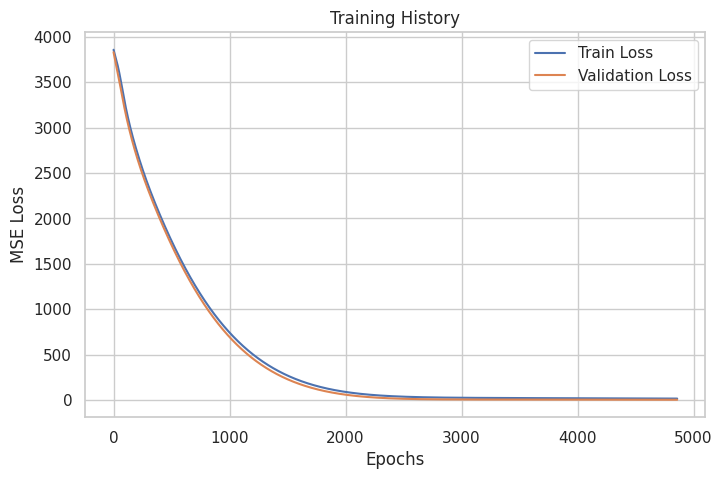

In [5]:
for hidden_size in [1, 5, 10, 15, 20, 25, 30]:
    print(f"\nTreinando modelo com hidden_size = {hidden_size}")
    
    model = models.Sequential([
        layers.SimpleRNN(
            hidden_size,
            return_sequences=True,
            input_shape=[3, 1],
            kernel_regularizer=regularizers.l2(0.01)  # Regularização L2
        ),
        layers.Dense(1, kernel_regularizer=regularizers.l2(0.01))
    ])
    
    compile_model(model, epochs=10000)
    model.save(f"content/models-no-shuffle/model_{hidden_size}.h5")

